# Implementing Naive Bayes Theorem

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load the dataset
df = pd.read_csv('NaiveBayesDataset.csv')

In [3]:
df

,Day,Discount,Free_Delivery,Purchase
0,Weekday,Yes,Yes,Yes
1,Weekday,Yes,Yes,Yes
2,Weekday,No,No,No
3,Holiday,Yes,Yes,Yes
4,Weekend,Yes,Yes,Yes
5,Holiday,No,No,No
6,Weekend,Yes,No,Yes
7,Weekday,Yes,Yes,Yes
8,Weekend,Yes,Yes,Yes
9,Holiday,Yes,Yes,Yes


In [4]:
# Encode categorical variables
label_encoders = {}
for column in ['Day', 'Discount', 'Free_Delivery', 'Purchase']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le 

In [5]:
 # Split data into features (X) and target (y)
X = df[['Day', 'Discount', 'Free_Delivery']]
y = df['Purchase']

In [6]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Initialize and train the Naive Bayes model
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

CategoricalNB()

In [8]:
# Make predictions on the test set
y_pred = nb_model.predict(X_test)

In [9]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [10]:
# Example prediction
example = pd.DataFrame({'Day': ['Holiday'], 'Discount': ['Yes'], 'Free_Delivery': ['No']})
for column in example.columns:
    example[column] = label_encoders[column].transform(example[column])
prediction = nb_model.predict(example)
print("Purchase Prediction:", label_encoders['Purchase']. inverse_transform(prediction))

Purchase Prediction: ['Yes']


In [11]:
# Check if "Holiday" exists in the Day encoder classes
print("Classes for Day:", label_encoders['Day'].classes_)

Classes for Day: ['Holiday' 'Weekday' 'Weekend']


In [12]:
# Example prediction
example = pd.DataFrame({'Day': ['Holiday'], 'Discount': ['Yes'], 'Free_Delivery': ['No']})
# This line creates a DataFrame named example with a single row representing an example input.

In [13]:
# Encode the example input using updated encoders
for column in example.columns:
    example[column] = label_encoders[column].transform(example[column])
#Purpose: This loop iterates over each column in the example DataFrame and transforms the categorical
#text values into numeric codes, which the model requires as input.

In [14]:
# Make prediction
prediction = nb_model.predict(example)
#Purpose: This line uses the Naive Bayes model (nb_model) to make a prediction
# on the transformed example input.

In [15]:
# Decode the prediction back to original label
print("Purchase Prediction:", label_encoders['Purchase'].inverse_transform(prediction))

Purchase Prediction: ['Yes']


In [16]:
# Example prediction
example = pd.DataFrame({'Day': ['Weekend'], 'Discount': ['Yes'], 'Free_Delivery': ['Yes']})
# This line creates a DataFrame named example with a single row representing an example input

In [17]:
# Encode the example input using updated encoders
for column in example.columns:
    example[column] = label_encoders[column].transform(example[column])
#Purpose: This loop iterates over each column in the example DataFrame and transforms the categorical
#text values into numeric codes, which the model requires as input.

In [18]:
# Make prediction
prediction = nb_model.predict(example)
#Purpose: This line uses the Naive Bayes model (nb_model) to make a prediction
# on the transformed example input.

In [19]:
# Decode the prediction back to original label
print("Purchase Prediction:", label_encoders['Purchase'].inverse_transform(prediction))

Purchase Prediction: ['Yes']


# Naive Bayes Classifier - Titanic

In [20]:
import pandas as pd

In [21]:
df= pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [22]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [23]:
# removing null values of Age// better if we remove later on the updated dataset
handle = df['Age'].mean()
handle

np.float64(30.272590361445783)

In [24]:
df.Age= df.Age.fillna(handle)

In [25]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,NaN,S


In [26]:
# Assumption: Make a naive assumption that features such as male,class,age,cabin,fare, etc. are independant of each other

In [27]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis ='columns',inplace= True)

In [28]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,34.5,7.8292
1,1,3,female,47.0,7.0000
2,0,2,male,62.0,9.6875
3,0,3,male,27.0,8.6625
4,1,3,female,22.0,12.2875


In [29]:
# 1 - survived 0 - not survived , At the end we will work on final
# obtained from inputs and targer for train_test_split()

In [30]:
# 1 - survived 0 - not survived 
inputs= df.drop('Survived', axis = 'columns')
target = df.Survived

In [31]:
# Encoding Sex
dummies = pd.get_dummies(df['Sex'])

In [32]:
dummies = dummies.astype(int)
# will display o and 1 instead of True and False

In [33]:
dummies

,female,male
0,0,1
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
413,0,1
414,1,0
415,0,1
416,0,1


In [34]:
#inputs = inputs.drop('Sex','male' axis='columns')

In [35]:
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,34.50000,7.8292
1,1,3,female,47.00000,7.0000
2,0,2,male,62.00000,9.6875
3,0,3,male,27.00000,8.6625
4,1,3,female,22.00000,12.2875
...,...,...,...,...,...
413,0,3,male,30.27259,8.0500
414,1,1,female,39.00000,108.9000
415,0,3,male,38.50000,7.2500
416,0,3,male,30.27259,8.0500


In [36]:
inputs

,Pclass,Sex,Age,Fare
0,3,male,34.50000,7.8292
1,3,female,47.00000,7.0000
2,2,male,62.00000,9.6875
3,3,male,27.00000,8.6625
4,3,female,22.00000,12.2875
...,...,...,...,...
413,3,male,30.27259,8.0500
414,1,female,39.00000,108.9000
415,3,male,38.50000,7.2500
416,3,male,30.27259,8.0500


In [37]:
inputs = inputs.drop(['Sex'] ,axis='columns')

In [38]:
inputs

,Pclass,Age,Fare
0,3,34.50000,7.8292
1,3,47.00000,7.0000
2,2,62.00000,9.6875
3,3,27.00000,8.6625
4,3,22.00000,12.2875
...,...,...,...
413,3,30.27259,8.0500
414,1,39.00000,108.9000
415,3,38.50000,7.2500
416,3,30.27259,8.0500


In [39]:
#concatening columns with sex column 
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,34.50000,7.8292
1,1,3,female,47.00000,7.0000
2,0,2,male,62.00000,9.6875
3,0,3,male,27.00000,8.6625
4,1,3,female,22.00000,12.2875
...,...,...,...,...,...
413,0,3,male,30.27259,8.0500
414,1,1,female,39.00000,108.9000
415,0,3,male,38.50000,7.2500
416,0,3,male,30.27259,8.0500


In [40]:
inputs

,Pclass,Age,Fare
0,3,34.50000,7.8292
1,3,47.00000,7.0000
2,2,62.00000,9.6875
3,3,27.00000,8.6625
4,3,22.00000,12.2875
...,...,...,...
413,3,30.27259,8.0500
414,1,39.00000,108.9000
415,3,38.50000,7.2500
416,3,30.27259,8.0500


In [41]:
merged = pd.concat([inputs,dummies],axis = 'columns')

In [42]:
merged

,Pclass,Age,Fare,female,male
0,3,34.50000,7.8292,0,1
1,3,47.00000,7.0000,1,0
2,2,62.00000,9.6875,0,1
3,3,27.00000,8.6625,0,1
4,3,22.00000,12.2875,1,0
...,...,...,...,...,...
413,3,30.27259,8.0500,0,1
414,1,39.00000,108.9000,1,0
415,3,38.50000,7.2500,0,1
416,3,30.27259,8.0500,0,1


In [43]:
final = merged.drop(['male'],axis ='columns')

In [44]:
final

,Pclass,Age,Fare,female
0,3,34.50000,7.8292,0
1,3,47.00000,7.0000,1
2,2,62.00000,9.6875,0
3,3,27.00000,8.6625,0
4,3,22.00000,12.2875,1
...,...,...,...,...
413,3,30.27259,8.0500,0
414,1,39.00000,108.9000,1
415,3,38.50000,7.2500,0
416,3,30.27259,8.0500,0


In [45]:
final.columns[final.isna().any()]

Index(['Fare'], dtype='str')

In [46]:
null_count_city = df['Fare'].isnull().sum()
print(f"Number of null values in 'Fare' column: {null_count_city}")

Number of null values in 'Fare' column: 1


In [47]:
final.Fare[:50]

0       7.8292
1       7.0000
2       9.6875
3       8.6625
4      12.2875
5       9.2250
6       7.6292
7      29.0000
8       7.2292
9      24.1500
10      7.8958
11     26.0000
12     82.2667
13     26.0000
14     61.1750
15     27.7208
16     12.3500
17      7.2250
18      7.9250
19      7.2250
20     59.4000
21      3.1708
22     31.6833
23     61.3792
24    262.3750
25     14.5000
26     61.9792
27      7.2250
28     30.5000
29     21.6792
30     26.0000
31     31.5000
32     20.5750
33     23.4500
34     57.7500
35      7.2292
36      8.0500
37      8.6625
38      9.5000
39     56.4958
40     13.4167
41     26.5500
42      7.8500
43     13.0000
44     52.5542
45      7.9250
46     29.7000
47      7.7500
48     76.2917
49     15.9000
Name: Fare, dtype: float64

In [48]:
final.Fare = final.Fare.fillna(final.Fare.mean())
final.head()

,Pclass,Age,Fare,female
0,3,34.5,7.8292,0
1,3,47.0,7.0000,1
2,2,62.0,9.6875,0
3,3,27.0,8.6625,0
4,3,22.0,12.2875,1


In [49]:
from sklearn.model_selection import train_test_split

In [50]:
xtrain, xtest, ytrain, ytest = train_test_split(final, target, test_size = 0.30, random_state =1)

In [51]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB ()

In [52]:
model.fit(xtrain, ytrain)

GaussianNB()

In [53]:
model.score(xtest,ytest)

1.0

In [54]:
xtest[:10]

,Pclass,Age,Fare,female
358,3,30.27259,7.7500,0
164,2,41.00000,13.0000,0
17,3,21.00000,7.2250,0
67,1,47.00000,42.4000,0
4,3,22.00000,12.2875,1
377,2,21.00000,11.5000,0
214,3,38.00000,7.7750,1
290,1,30.27259,39.6000,0
381,3,26.00000,7.8792,0
5,3,14.00000,9.2250,0


In [55]:
ytest[0:10]

358    0
164    0
17     0
67     0
4      1
377    0
214    1
290    0
381    0
5      0
Name: Survived, dtype: int64

In [56]:
model.predict(xtest[0:10])

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

In [57]:
model.predict_proba(xtest[:10])

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [58]:
#pclass, Age, Fare, Gender

test = [[1,23.000000,113.2750,0]]
#test = xtest
a= model.predict(test)
if a[0] == 0:
    print("Not Survived")
else: 
    print(" Survived")

Not Survived


/media/spyder/Secondary-Disk/Github/Student-Performance-Prediction-with-Explainable-AI/CodeBase/Trial/.spenv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


## Calculate value with cross validation

In [59]:
from sklearn.model_selection import cross_val_score

In [60]:
cross_val_score (GaussianNB(),xtrain,ytrain,cv = 5)

array([1., 1., 1., 1., 1.])

# Feature-selection-stdm

## Univariate Selecetion Method @Feature Selection, Algorithm: SelectKBest Algorithm

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns

In [62]:
#df = pd.read_csv("bank.csv",sep = ';')
df = pd.read_csv("cardio_train.csv", sep = ';')

In [63]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [64]:
df.shape

(70000, 13)

In [65]:
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

<Axes: ylabel='count'>

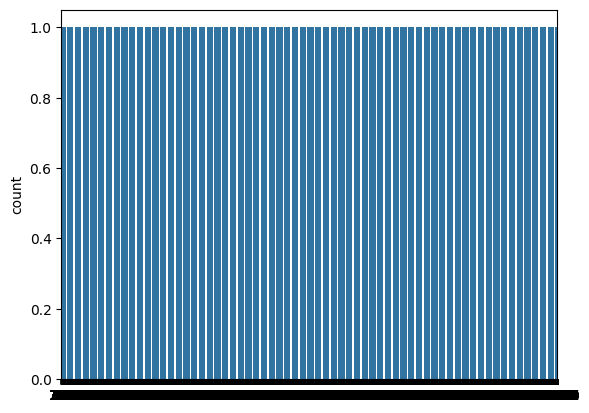

In [66]:
sns.countplot(df["cardio"])

- x = df.iloc[:, :-1]: 
- This line is selecting all rows (:) and all columns except the last one (:-1). 
- : means "select all rows." 
- :-1 means "select all columns except the last one." In Python slicing, :-1 excludes the last item, so this will include all columns up to, but not ncluding, the last one. 
- Result: x will be a DataFrame containing all the columns of df except the last column 

In [67]:
x = df.iloc[: , :-1]

- y = df.iloc[:, 12]
- This line is selecting all rows (:) and the 13th column (remember, indexing in Python starts at 0, so index 12 corresponds to the 13th column).
- : means "select all rows."
- 12 means "select the 13th column" (as Python uses 0-based indexing).
- Result: y will be a Series containing the values of the 13th column of df.

In [68]:
# y = df.iloc[:, 12]
y = df.iloc [: ,12]

In [69]:
from sklearn.feature_selection import SelectKBest

In [70]:
from sklearn.feature_selection import f_classif

In [71]:
FIT_FEATURES= SelectKBest(score_func = f_classif)

In [72]:
FIT_FEATURES.fit(x,y)

SelectKBest()

In [73]:
pd.DataFrame(FIT_FEATURES.scores_)

,0
0,1.010461
1,4209.007957
2,4.603641
3,8.197397
4,2388.777887
5,208.339524
6,303.629011
7,3599.361137
8,562.772977
9,16.790541


In [74]:
score_COL = pd.DataFrame(FIT_FEATURES.scores_)

In [75]:
score_COL

,0
0,1.010461
1,4209.007957
2,4.603641
3,8.197397
4,2388.777887
5,208.339524
6,303.629011
7,3599.361137
8,562.772977
9,16.790541


In [76]:
# Assuming FIT_FEATURES_scores is an array or a list of scores
score_COL = pd.DataFrame(FIT_FEATURES.scores_, columns=["scorevalue"])
# Now score_COL is a DataFrame with a single column named "scorevalue"

In [77]:
score_COL

,scorevalue
0,1.010461
1,4209.007957
2,4.603641
3,8.197397
4,2388.777887
5,208.339524
6,303.629011
7,3599.361137
8,562.772977
9,16.790541


In [78]:
NEW_COL = pd.DataFrame(x.columns)

In [79]:
NEW_COL

,0
0,id
1,age
2,gender
3,height
4,weight
5,ap_hi
6,ap_lo
7,cholesterol
8,gluc
9,smoke


In [80]:
top_features = pd.concat([NEW_COL, score_COL], axis=1)

In [81]:
top_features

,0,scorevalue
0,id,1.010461
1,age,4209.007957
2,gender,4.603641
3,height,8.197397
4,weight,2388.777887
5,ap_hi,208.339524
6,ap_lo,303.629011
7,cholesterol,3599.361137
8,gluc,562.772977
9,smoke,16.790541


In [82]:
top_features.nlargest (8,"scorevalue")

,0,scorevalue
1,age,4209.007957
7,cholesterol,3599.361137
4,weight,2388.777887
8,gluc,562.772977
6,ap_lo,303.629011
5,ap_hi,208.339524
11,active,89.091494
9,smoke,16.790541


# Feature-selection-using-correlation

In [142]:
import pandas as pd
# Load the dataset
df = pd.read_csv('feature_selection.csv')

In [143]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,a,dhaka,3,2,x,o+,10000
1,b,dhaka,4,2,y,ab+,12000
2,c,khulna,2,2,p,ab-,11000
3,d,rajshahi,3,2,q,o+,15000
4,e,cumilla,3,1,w,ab+,12000
5,f,dhaka,2,1,l,ab-,11000
6,g,barishal,2,1,r,o+,10000
7,h,natore,2,3,s,o+,15000
8,i,khulna,3,3,k,ab+,12000
9,j,dhaka,4,2,v,ab-,11000


In [144]:
# Check for non-numeric data in the columns
print(df.dtypes)

location         str
area             str
bedroom        int64
bathroom       int64
owner            str
blodd group      str
price          int64
dtype: object


In [145]:
 # Identify non-numeric values in specific columns
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Non-numeric values in '{column}':\n", df[column].unique())

In [146]:
# Option 1: Convert columns to numeric, forcing errors to NaN
df = df.apply(pd.to_numeric, errors='coerce')

In [147]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,NaN,NaN,3,2,NaN,NaN,10000
1,NaN,NaN,4,2,NaN,NaN,12000
2,NaN,NaN,2,2,NaN,NaN,11000
3,NaN,NaN,3,2,NaN,NaN,15000
4,NaN,NaN,3,1,NaN,NaN,12000
5,NaN,NaN,2,1,NaN,NaN,11000
6,NaN,NaN,2,1,NaN,NaN,10000
7,NaN,NaN,2,3,NaN,NaN,15000
8,NaN,NaN,3,3,NaN,NaN,12000
9,NaN,NaN,4,2,NaN,NaN,11000


In [148]:
 # Calculate correlation with the target variable 'price'
correlation = df.corr()

In [149]:
print(df.dtypes)

location       float64
area           float64
bedroom          int64
bathroom         int64
owner          float64
blodd group    float64
price            int64
dtype: object


In [150]:
# Option 1: Convert columns to numeric, forcing errors to NaN
df = df.apply(pd.to_numeric, errors='coerce')

In [151]:
# Calculate correlation with the target variable 'price'
correlation = df.corr()

In [152]:
# Display the correlation of each feature with the target variable 'price'
correlated_features = correlation['price'].sort_values(ascending=False)
print("Correlation with Price:\n", correlated_features)

Correlation with Price:
 price          1.000000
bathroom       0.495798
bedroom       -0.015721
location            NaN
area                NaN
owner               NaN
blodd group         NaN
Name: price, dtype: float64


## Encoding / Handling another column => location

In [191]:
from sklearn.preprocessing import OrdinalEncoder
# Load the dataset
df = pd.read_csv('feature_selection.csv')

In [192]:
categorical_column = 'location'

In [193]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,a,dhaka,3,2,x,o+,10000
1,b,dhaka,4,2,y,ab+,12000
2,c,khulna,2,2,p,ab-,11000
3,d,rajshahi,3,2,q,o+,15000
4,e,cumilla,3,1,w,ab+,12000
5,f,dhaka,2,1,l,ab-,11000
6,g,barishal,2,1,r,o+,10000
7,h,natore,2,3,s,o+,15000
8,i,khulna,3,3,k,ab+,12000
9,j,dhaka,4,2,v,ab-,11000


In [194]:
print(df.columns)

Index(['location ', 'area ', 'bedroom ', 'bathroom', 'owner ', 'blodd group',
       'price'],
      dtype='str')


In [195]:
df.columns = df.columns.str.strip() # Remove any leading/trailing spaces
df.columns = df.columns.str.lower() # Convert all column names to lowercase (optional)
print(df.columns)


Index(['location', 'area', 'bedroom', 'bathroom', 'owner', 'blodd group',
       'price'],
      dtype='str')


In [196]:
# Optional: Use a conditional check
if 'location' in df.columns:
    print(df['location'].head())
else:
    print("The 'location' column is not in the DataFrame.")

0    a
1    b
2    c
3    d
4    e
Name: location, dtype: str


In [197]:
encoder = OrdinalEncoder()
df[categorical_column] = encoder.fit_transform(df[[categorical_column]])

In [198]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,0.0,dhaka,3,2,x,o+,10000
1,1.0,dhaka,4,2,y,ab+,12000
2,2.0,khulna,2,2,p,ab-,11000
3,3.0,rajshahi,3,2,q,o+,15000
4,4.0,cumilla,3,1,w,ab+,12000
5,5.0,dhaka,2,1,l,ab-,11000
6,6.0,barishal,2,1,r,o+,10000
7,7.0,natore,2,3,s,o+,15000
8,8.0,khulna,3,3,k,ab+,12000
9,9.0,dhaka,4,2,v,ab-,11000


# Feature Selection using Correlation -U 

In [169]:
import pandas as pd
# Load the dataset
df = pd.read_csv('feature_selection.csv')

In [170]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,a,dhaka,3,2,x,o+,10000
1,b,dhaka,4,2,y,ab+,12000
2,c,khulna,2,2,p,ab-,11000
3,d,rajshahi,3,2,q,o+,15000
4,e,cumilla,3,1,w,ab+,12000
5,f,dhaka,2,1,l,ab-,11000
6,g,barishal,2,1,r,o+,10000
7,h,natore,2,3,s,o+,15000
8,i,khulna,3,3,k,ab+,12000
9,j,dhaka,4,2,v,ab-,11000


In [171]:
#  Check for non-numeric data in the columns
print(df.dtypes)

location         str
area             str
bedroom        int64
bathroom       int64
owner            str
blodd group      str
price          int64
dtype: object


In [172]:
# Identify non-numeric values in specific columns
for column in df.columns:
     if df[column].dtype == 'object':
         print(f"Non-numeric values in '{column}':\n", df[column].unique())

## Encoding / Handling another column => location#

In [173]:
from sklearn.preprocessing import OrdinalEncoder
categorical_column = 'location'
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,a,dhaka,3,2,x,o+,10000
1,b,dhaka,4,2,y,ab+,12000
2,c,khulna,2,2,p,ab-,11000
3,d,rajshahi,3,2,q,o+,15000
4,e,cumilla,3,1,w,ab+,12000
5,f,dhaka,2,1,l,ab-,11000
6,g,barishal,2,1,r,o+,10000
7,h,natore,2,3,s,o+,15000
8,i,khulna,3,3,k,ab+,12000
9,j,dhaka,4,2,v,ab-,11000


In [175]:
print(df.columns)

Index(['location ', 'area ', 'bedroom ', 'bathroom', 'owner ', 'blodd group',
       'price'],
      dtype='str')


In [176]:
df.columns = df.columns.str.strip() # Remove any leading/trailing spaces
df.columns = df.columns.str.lower() # Convert all column names to lowercase (o
print(df.columns)

Index(['location', 'area', 'bedroom', 'bathroom', 'owner', 'blodd group',
       'price'],
      dtype='str')


In [177]:
# Optional: Use a conditional check
if 'location' in df.columns:
 print(df['location'].head())
else:
 print("The 'location' column is not in the DataFrame.")

0    a
1    b
2    c
3    d
4    e
Name: location, dtype: str


In [178]:
encoder = OrdinalEncoder()
df[categorical_column] = encoder.fit_transform(df[[categorical_column]])

In [179]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,0.0,dhaka,3,2,x,o+,10000
1,1.0,dhaka,4,2,y,ab+,12000
2,2.0,khulna,2,2,p,ab-,11000
3,3.0,rajshahi,3,2,q,o+,15000
4,4.0,cumilla,3,1,w,ab+,12000
5,5.0,dhaka,2,1,l,ab-,11000
6,6.0,barishal,2,1,r,o+,10000
7,7.0,natore,2,3,s,o+,15000
8,8.0,khulna,3,3,k,ab+,12000
9,9.0,dhaka,4,2,v,ab-,11000


## Encoding / Handling another column => area

In [180]:
categorical_column = 'area'

In [181]:
encoder = OrdinalEncoder()
df[categorical_column] = encoder.fit_transform(df[[categorical_column]])

In [182]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,0.0,2.0,3,2,x,o+,10000
1,1.0,2.0,4,2,y,ab+,12000
2,2.0,3.0,2,2,p,ab-,11000
3,3.0,5.0,3,2,q,o+,15000
4,4.0,1.0,3,1,w,ab+,12000
5,5.0,2.0,2,1,l,ab-,11000
6,6.0,0.0,2,1,r,o+,10000
7,7.0,4.0,2,3,s,o+,15000
8,8.0,3.0,3,3,k,ab+,12000
9,9.0,2.0,4,2,v,ab-,11000


## Encoding more than one column at a time

In [183]:
categorical_columns = ['owner', 'blodd group'] 

In [184]:
for column in categorical_columns:
    if column not in df.columns:
         print(f"Column '{column}' does not exist in the DataFrame")
    else:
         print(f"Encoding column: {column}")

Encoding column: owner
Encoding column: blodd group


In [187]:
encoder = OrdinalEncoder()
existing_categorical_columns = [col for col in categorical_columns if col in df]
df[existing_categorical_columns] = encoder.fit_transform(df[existing_categorical_columns])

In [188]:
df

,location,area,bedroom,bathroom,owner,blodd group,price
0,0.0,2.0,3,2,8.0,2.0,10000
1,1.0,2.0,4,2,9.0,0.0,12000
2,2.0,3.0,2,2,2.0,1.0,11000
3,3.0,5.0,3,2,3.0,2.0,15000
4,4.0,1.0,3,1,7.0,0.0,12000
5,5.0,2.0,2,1,1.0,1.0,11000
6,6.0,0.0,2,1,4.0,2.0,10000
7,7.0,4.0,2,3,5.0,2.0,15000
8,8.0,3.0,3,3,0.0,0.0,12000
9,9.0,2.0,4,2,6.0,1.0,11000


In [189]:
# Calculate correlation with the target variable 'price'
correlation = df.corr()

In [190]:
# Display the correlation of each feature with the target variable 'price'
correlated_features = correlation['price'].sort_values(ascending=False)
print("Correlation with Price:\n", correlated_features)

Correlation with Price:
 price          1.000000
area           0.797921
bathroom       0.495798
blodd group    0.148712
location       0.133118
bedroom       -0.015721
owner         -0.092159
Name: price, dtype: float64
